In [ ]:
import re
from collections import Counter

import json
from pathlib import Path

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import entropy

from readers.rais_reader import RaisReader

from discovery.ftp_client import FTPClient
from discovery.filename_parser import RaisFilenameParser
from discovery.dataset_selector import RaisDatasetSelector

from profiling.schema_profiler import RaisSchemaProfiler

In [ ]:
# Data paths

client_path = Path("/pdet/microdados/RAIS")

extracted_data_path = Path("data/extracted")

dict_dir = Path("dictionaries")

In [27]:
def save_json(path, doc):
    with open(path , "w") as file:
        json.dump(doc, file)

def load_json(path):
    def hint_tuples(item):
        if isinstance(item, dict):
            return {int(k) if k.isdigit() else k: v for k, v in item.items()}
        return item
    
    with open(path, "r") as file:
        arquivos = json.load(file, object_hook=hint_tuples)
    return arquivos

## Preprocessamento

In [4]:
# Faz parsing dos arquivos e seleciona os relevantes

client = FTPClient("ftp.mtps.gov.br")

client.connect()

arquivos = {}

for year in range(2024, 2025):
    try:
        arquivos[year] = client.list_directory(str(client_path.joinpath(str(year))))

        parser = RaisFilenameParser()

        parsed = [
            parser.parse(a) for a in arquivos[year]
        ]

        selector = RaisDatasetSelector()

        arquivos[year] = selector.select_valid_datasets(parsed)
            
    except Exception as e:
        print(e)
        continue

client.disconnect()

In [153]:
# Extrai schema dos dados

profiler = RaisSchemaProfiler()

profiles = []

for year in range(2024, 2025):
    path = extracted_data_path.joinpath(str(year))
    
    if(not path.exists()):
        continue

    arquivos_extracted = [item for item in path.iterdir() if item.is_file()]

    for a in arquivos_extracted:
        profile = profiler.profile_schema(a)

        arquivo = next((item for item in arquivos[year] if item['stem'] == profile['file_name'].split('.')[0]))
        arquivo['profile'] = profile

In [154]:
save_json("gov/rais/data/arquivos.json", arquivos)

## Leitura e processamento

#### Leitura

In [ ]:
arquivos = load_json("data/arquivos.json")

In [29]:
reader = RaisReader()

In [30]:
data = {}
ds_type = "vinculo"

for year in range(2024, 2025):
    n_arqs = 0

    data[year] = {}
    for arquivo in arquivos[year]:
        n_arqs += 1

        if not arquivo["dataset_type"] == ds_type:
            continue
        if arquivo.get("profile"):
            profile = arquivo["profile"]

            data[year][arquivo["stem"]] = {}

            reader.configure(
                encoding=profile["encoding"],
                separator=profile["separator"]
            )

            filepath = (extracted_data_path/str(year)/profile["file_name"])

            print(filepath)
            for i, chunk in enumerate(reader.read(filepath)):
                data[year][arquivo['stem']][i] = chunk

                if(i==1):
                    break

gov/rais/data/extracted/2024/RAIS_VINC_PUB_CENTRO_OESTE.COMT
[Chunk 0] Rows=100000
[Chunk 1] Rows=100000
gov/rais/data/extracted/2024/RAIS_VINC_PUB_MG_ES_RJ.COMT
[Chunk 0] Rows=100000
[Chunk 1] Rows=100000
gov/rais/data/extracted/2024/RAIS_VINC_PUB_NORDESTE.COMT
[Chunk 0] Rows=100000
[Chunk 1] Rows=100000
gov/rais/data/extracted/2024/RAIS_VINC_PUB_NORTE.COMT
[Chunk 0] Rows=100000
[Chunk 1] Rows=100000
gov/rais/data/extracted/2024/RAIS_VINC_PUB_SP.COMT
[Chunk 0] Rows=100000
[Chunk 1] Rows=100000
gov/rais/data/extracted/2024/RAIS_VINC_PUB_SUL.COMT
[Chunk 0] Rows=100000
[Chunk 1] Rows=100000


#### Normalização

In [ ]:
from normalization.normalizer import RaisNormalizer

In [32]:
normalizer = RaisNormalizer()

In [33]:
dfs = []

for regiao in data[2024]:
    for i in range(len(data[2024][regiao])):
        chunk = data[2024][regiao][i]
        chunk = normalizer.normalize(
            chunk,
            dataset_type="vinculo"
        )
        dfs.append(chunk)

df = pd.concat(dfs).reset_index()

In [34]:
df = df.drop("sigla_uf", axis=1)

#### Seleção de colunas

In [36]:
municipios = pd.read_csv("gov/rais/dictionaries/id_municipio.csv")

municipios = municipios[["id_municipio_6", "sigla_uf", "nome_uf"]].drop_duplicates()

municipios = municipios.rename(columns={"id_municipio_6": "id_municipio"})

In [37]:
df = df.merge(municipios, on="id_municipio", how="left")

In [38]:
cols = [
    "sexo",
    "raca_cor",
    "faixa_etaria",
    "grau_instrucao_apos_2005",
    "sigla_uf",
    "tamanho_estabelecimento",
    "tipo_vinculo",
    "categoria_trabalhador",
    "subsetor_ibge",
    "valor_remuneracao_media"
]

df = df[cols]

In [39]:
df

,sexo,raca_cor,faixa_etaria,grau_instrucao_apos_2005,sigla_uf,tamanho_estabelecimento,tipo_vinculo,categoria_trabalhador,subsetor_ibge,valor_remuneracao_media
0,2,8,4,7,GO,2,60,101,16,0.0
1,1,8,5,7,MS,5,10,101,4,0.0
2,1,2,7,10,DF,10,35,302,19,0.0
3,2,2,7,9,DF,10,30,301,24,0.0
4,1,8,7,9,GO,5,25,101,25,0.0
...,...,...,...,...,...,...,...,...,...,...
1199995,2,9,7,9,RS,10,30,301,24,0.0
1199996,1,8,4,7,SC,2,10,101,16,0.0
1199997,2,2,6,9,RS,10,96,306,24,0.0
1199998,1,2,6,7,RS,3,10,101,16,0.0


#### Tradução

In [40]:
df = df[
    df["valor_remuneracao_media"] > 0
].copy()

In [41]:
categorical_cols = [
    "sexo",
    "raca_cor",
    "faixa_etaria",
    "grau_instrucao_apos_2005",
    "tamanho_estabelecimento",
    "tipo_vinculo",
    "categoria_trabalhador",
    "subsetor_ibge"
]

In [42]:
def apply_dictionary(df, column, dictionaries_path):
    path = dictionaries_path / f"{column}.csv"

    dictionary = pd.read_csv(path)

    dictionary = dictionary.copy()

    dictionary["chave"] = pd.to_numeric(dictionary["chave"], errors="coerce")

    dictionary = dictionary.dropna(subset=["chave"])

    dictionary["chave"] = dictionary["chave"].astype(int)

    mapping = dict(
        zip(dictionary["chave"], dictionary["valor"])
    )

    df[column] = df[column].map(mapping)

    return df

In [43]:
for col in categorical_cols:
    df = apply_dictionary(df, col, dict_dir)

In [44]:
df

,sexo,raca_cor,faixa_etaria,grau_instrucao_apos_2005,sigla_uf,tamanho_estabelecimento,tipo_vinculo,categoria_trabalhador,subsetor_ibge,valor_remuneracao_media
433,Masculino,Parda,18 a 24 anos,SUP. INCOMP,DF,De 500 a 999,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,"Com. e administraçao de imóveis, valores mobil...",2548.01
434,Feminino,Parda,40 a 49 anos,MEDIO COMPL,GO,De 10 a 19,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,"Serviços médicos, odontológicos e veterinários",1694.40
435,Masculino,Branca,50 a 64 anos,MEDIO COMPL,GO,De 10 a 19,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,Comércio atacadista,2023.05
436,Masculino,Branca,30 a 39 anos,MEDIO COMPL,DF,DE 5 A 9,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,"Instituiçoes de crédito, seguros e capitalizaçao",8083.22
437,Masculino,Parda,40 a 49 anos,MEDIO INCOMP,GO,De 5 a 9,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,"Com. e administraçao de imóveis, valores mobil...",3162.18
...,...,...,...,...,...,...,...,...,...,...
1199883,Masculino,Parda,18 a 24 anos,MEDIO INCOMP,SC,De 250 a 499,CLT U/PJ DET,Empregado - Geral inclusive o empregado públi...,Comércio atacadista,1324.19
1199884,Masculino,Branca,18 a 24 anos,6. A 9. FUND,RS,De 100 a 249,CLT R/PJ DET,Empregado - Geral inclusive o empregado públi...,"Agricultura, silvicultura, criaçao de animais,...",1024.05
1199885,Feminino,Indígena,25 a 29 anos,MEDIO COMPL,RS,De 10 a 19,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,Comércio varejista,2425.82
1199886,Masculino,Branca,18 a 24 anos,MEDIO INCOMP,RS,DE 5 A 9,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,"Com. e administraçao de imóveis, valores mobil...",1741.58


#### Limpeza

In [45]:
for col in categorical_cols:
    print("\n")
    print(df[col].value_counts().head(10))



sexo
Masculino    388252
Feminino     286613
Name: count, dtype: int64


raca_cor
Parda               328801
Branca              260513
Preta                42176
Não identificado     33478
Amarela               6798
Indígena              3099
Name: count, dtype: int64


faixa_etaria
30 a 39 anos       177860
40 a 49 anos       161847
50 a 64 anos       120536
18 a 24 anos       101356
25 a 29 anos        92915
65 anos ou mais     16117
15 a 17 anos         4150
10 a 14 anos           84
Name: count, dtype: int64


grau_instrucao_apos_2005
MEDIO COMPL     330168
SUP. COMP       183185
FUND COMPL       43507
MEDIO INCOMP     37006
6. A 9. FUND     26345
SUP. INCOMP      19435
ATE 5.A INC      14529
5.A CO FUND       8714
MESTRADO          5721
ANALFABETO        3213
Name: count, dtype: int64


tamanho_estabelecimento
IGNORADO        187262
De 20 a 49       73010
De 100 a 249     68887
De 500 a 999     60465
De 10 a 19       58813
DE 5 A 9         55253
De 250 a 499     54980
De 50 a 9

In [46]:
INVALID_VALUES = [
    "Não identificado",
    "IGNORADO",
    "Código não encontrado nos dicionários oficiais."
]

In [47]:
for col in [
    "sexo",
    "raca_cor",
    "faixa_etaria",
    "grau_instrucao_apos_2005",
    "tamanho_estabelecimento",
    "tipo_vinculo",
    "categoria_trabalhador",
    "subsetor_ibge",
]:
    df = df[
        ~df[col].isin(INVALID_VALUES)
    ]

In [48]:
df = df.dropna()

In [49]:
df

,sexo,raca_cor,faixa_etaria,grau_instrucao_apos_2005,sigla_uf,tamanho_estabelecimento,tipo_vinculo,categoria_trabalhador,subsetor_ibge,valor_remuneracao_media
433,Masculino,Parda,18 a 24 anos,SUP. INCOMP,DF,De 500 a 999,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,"Com. e administraçao de imóveis, valores mobil...",2548.01
434,Feminino,Parda,40 a 49 anos,MEDIO COMPL,GO,De 10 a 19,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,"Serviços médicos, odontológicos e veterinários",1694.40
435,Masculino,Branca,50 a 64 anos,MEDIO COMPL,GO,De 10 a 19,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,Comércio atacadista,2023.05
436,Masculino,Branca,30 a 39 anos,MEDIO COMPL,DF,DE 5 A 9,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,"Instituiçoes de crédito, seguros e capitalizaçao",8083.22
437,Masculino,Parda,40 a 49 anos,MEDIO INCOMP,GO,De 5 a 9,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,"Com. e administraçao de imóveis, valores mobil...",3162.18
...,...,...,...,...,...,...,...,...,...,...
1199883,Masculino,Parda,18 a 24 anos,MEDIO INCOMP,SC,De 250 a 499,CLT U/PJ DET,Empregado - Geral inclusive o empregado públi...,Comércio atacadista,1324.19
1199884,Masculino,Branca,18 a 24 anos,6. A 9. FUND,RS,De 100 a 249,CLT R/PJ DET,Empregado - Geral inclusive o empregado públi...,"Agricultura, silvicultura, criaçao de animais,...",1024.05
1199885,Feminino,Indígena,25 a 29 anos,MEDIO COMPL,RS,De 10 a 19,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,Comércio varejista,2425.82
1199886,Masculino,Branca,18 a 24 anos,MEDIO INCOMP,RS,DE 5 A 9,CLT U/PJ IND,Empregado - Geral inclusive o empregado públi...,"Com. e administraçao de imóveis, valores mobil...",1741.58


## Subset Mining

### Pysubgroup

#### Utils

In [50]:
# !pip install pysubgroup

In [51]:
import pysubgroup as ps

In [52]:
def create_target(df, percentile):
    threshold = df["valor_remuneracao_media"].quantile(percentile)

    target_col = f"target_p{int(percentile * 100)}"

    df[target_col] = (
        df["valor_remuneracao_media"] >= threshold
    )

    print(f"\nPercentil {percentile:.0%}")
    print(f"Threshold: R$ {threshold:.2f}")
    print(df[target_col].value_counts())
    print(df[target_col].value_counts(normalize=True))

    return target_col, threshold

In [53]:
target_p90, p90 = create_target(df, 0.90)
target_p95, p95 = create_target(df, 0.95)
target_p99, p99 = create_target(df, 0.99)


Percentil 90%
Threshold: R$ 5264.20
target_p90
False    419322
True      46594
Name: count, dtype: int64
target_p90
False    0.899995
True     0.100005
Name: proportion, dtype: float64

Percentil 95%
Threshold: R$ 7874.36
target_p95
False    442620
True      23296
Name: count, dtype: int64
target_p95
False    0.95
True     0.05
Name: proportion, dtype: float64

Percentil 99%
Threshold: R$ 19371.97
target_p99
False    461256
True       4660
Name: count, dtype: int64
target_p99
False    0.989998
True     0.010002
Name: proportion, dtype: float64


In [54]:
mining_df = df.copy()

for col in [
    "sexo",
    "raca_cor",
    "faixa_etaria",
    "grau_instrucao_apos_2005",
    "sigla_uf",
    "tamanho_estabelecimento",
    "tipo_vinculo",
    "categoria_trabalhador",
    "subsetor_ibge"
]:
    mining_df[col] = mining_df[col].astype(str)

In [81]:
len(mining_df), mining_df.shape

(465916, (465916, 13))

In [82]:
search_space = ps.create_selectors(
    mining_df,
    ignore=[
        "valor_remuneracao_media",
        "target_p90",
        "target_p95",
        "target_p99"
    ]
)

In [83]:
def run_experiment(
    mining_df,
    target_column,
    search_space,
    depth=4,
    result_size=20
):
    target = ps.BinaryTarget(target_column, True)

    task = ps.SubgroupDiscoveryTask(
        mining_df,
        target,
        search_space,
        result_set_size=result_size,
        depth=depth,
        qf=ps.StandardQF(0.5)
    )

    result = ps.BeamSearch(beam_width=result_size*2).execute(task)

    return result

#### Experimento 1 - Redundancia

In [79]:
result_p90 = run_experiment(
    mining_df,
    "target_p90",
    search_space
)

/home/iago/Documents/Projects/Repositories/.venv/lib/python3.12/site-packages/pysubgroup/binary_target.py:508: RuntimeWarning: invalid value encountered in divide
  p_subgroup = np.divide(positives_subgroup, instances_subgroup)


In [84]:
result_p90_df = result_p90.to_dataframe()
result_p90_df.sort_values("quality", ascending=False)

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift
0,0.095470,grau_instrucao_apos_2005=='SUP. COMP',101239,465916,30859,46594,364677,0.217290,0.782710,0.662296,0.337704,0.304813,0.043148,0.100005,3.047977
1,0.083484,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,54836,465916,18828,46594,411080,0.117695,0.882305,0.404086,0.595914,0.343351,0.067544,0.100005,3.433334
2,0.082476,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,46778,465916,16854,46594,419138,0.100400,0.899600,0.361720,0.638280,0.360298,0.070955,0.100005,3.602790
3,0.076865,tipo_vinculo=='ESTATUTARIO',26339,465916,11149,46594,439577,0.056532,0.943468,0.239280,0.760720,0.423289,0.080634,0.100005,4.232669
4,0.074417,grau_instrucao_apos_2005=='SUP. COMP' AND tipo...,16393,465916,8143,46594,449523,0.035184,0.964816,0.174765,0.825235,0.496736,0.085537,0.100005,4.967108
5,0.073771,categoria_trabalhador==' Empregado - Geral inc...,57315,465916,17787,46594,408601,0.123016,0.876984,0.381744,0.618256,0.310338,0.070502,0.100005,3.103216
6,0.073649,grau_instrucao_apos_2005=='SUP. COMP' AND tipo...,57554,465916,17816,46594,408362,0.123529,0.876471,0.382367,0.617633,0.309553,0.070472,0.100005,3.095368
7,0.070963,categoria_trabalhador==' Empregado - Geral inc...,62816,465916,18422,46594,403100,0.134823,0.865177,0.395373,0.604627,0.293269,0.069888,0.100005,2.932541
8,0.070739,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,25239,465916,10195,46594,440677,0.054171,0.945829,0.218805,0.781195,0.403938,0.082598,0.100005,4.039175
9,0.069146,subsetor_ibge=='Administraçao pública direta e...,21955,465916,9189,46594,443961,0.047122,0.952878,0.197214,0.802786,0.418538,0.084253,0.100005,4.185164


In [80]:
result_p95 = run_experiment(
    mining_df,
    "target_p95",
    search_space
)

In [85]:
result_p95_df = result_p95.to_dataframe()
result_p95_df.sort_values("quality", ascending=False)

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift
0,0.057675,grau_instrucao_apos_2005=='SUP. COMP',101239,465916,17588,23296,364677,0.217290,0.782710,0.754979,0.245021,0.173728,0.015652,0.05,3.474520
1,0.056879,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,46778,465916,10736,23296,419138,0.100400,0.899600,0.460852,0.539148,0.229510,0.029966,0.05,4.590153
2,0.053010,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,54836,465916,11215,23296,411080,0.117695,0.882305,0.481413,0.518587,0.204519,0.029388,0.05,4.090343
3,0.050858,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,25239,465916,6777,23296,440677,0.054171,0.945829,0.290908,0.709092,0.268513,0.037486,0.05,5.370214
4,0.049180,tipo_vinculo=='ESTATUTARIO',26339,465916,6765,23296,439577,0.056532,0.943468,0.290393,0.709607,0.256843,0.037607,0.05,5.136825
5,0.048508,grau_instrucao_apos_2005=='SUP. COMP' AND tipo...,16393,465916,5059,23296,449523,0.035184,0.964816,0.217162,0.782838,0.308607,0.040570,0.05,6.172094
6,0.045611,categoria_trabalhador==' Empregado - Geral inc...,25768,465916,6286,23296,440148,0.055306,0.944694,0.269832,0.730168,0.243946,0.038646,0.05,4.878878
7,0.045542,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,25853,465916,6291,23296,440063,0.055489,0.944511,0.270046,0.729954,0.243337,0.038642,0.05,4.866705
8,0.044481,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,13729,465916,4244,23296,452187,0.029467,0.970533,0.182177,0.817823,0.309127,0.042133,0.05,6.182480
9,0.044248,subsetor_ibge=='Administraçao pública direta e...,21955,465916,5573,23296,443961,0.047122,0.952878,0.239226,0.760774,0.253837,0.039920,0.05,5.076704


In [86]:
result_p99 = run_experiment(
    mining_df,
    "target_p99",
    search_space
)

/home/iago/Documents/Projects/Repositories/.venv/lib/python3.12/site-packages/pysubgroup/binary_target.py:508: RuntimeWarning: invalid value encountered in divide
  p_subgroup = np.divide(positives_subgroup, instances_subgroup)


In [38]:
result_p99_df = result_p99.to_dataframe()
result_p99_df.sort_values("quality", ascending=False)

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift
0,0.016272,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,25239,465916,2017,4660,440677,0.054171,0.945829,0.432833,0.567167,0.079916,0.005998,0.010002,7.990160
1,0.016027,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,46778,465916,2834,4660,419138,0.100400,0.899600,0.608155,0.391845,0.060584,0.004357,0.010002,6.057311
2,0.014583,"subsetor_ibge=='Instituiçoes de crédito, segur...",1118,465916,344,4660,464798,0.002400,0.997600,0.073820,0.926180,0.307692,0.009286,0.010002,30.763684
3,0.014583,categoria_trabalhador==' Contribuinte individu...,1118,465916,344,4660,464798,0.002400,0.997600,0.073820,0.926180,0.307692,0.009286,0.010002,30.763684
4,0.014583,categoria_trabalhador==' Contribuinte individu...,1118,465916,344,4660,464798,0.002400,0.997600,0.073820,0.926180,0.307692,0.009286,0.010002,30.763684
5,0.014039,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,1069,465916,324,4660,464847,0.002294,0.997706,0.069528,0.930472,0.303087,0.009328,0.010002,30.303236
6,0.014039,categoria_trabalhador==' Contribuinte individu...,1069,465916,324,4660,464847,0.002294,0.997706,0.069528,0.930472,0.303087,0.009328,0.010002,30.303236
7,0.014039,categoria_trabalhador==' Contribuinte individu...,1069,465916,324,4660,464847,0.002294,0.997706,0.069528,0.930472,0.303087,0.009328,0.010002,30.303236
8,0.013848,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,54836,465916,2762,4660,411080,0.117695,0.882305,0.592704,0.407296,0.050368,0.004617,0.010002,5.035929
9,0.013664,faixa_etaria=='50 a 64 anos' AND grau_instruca...,9603,465916,1010,4660,456313,0.020611,0.979389,0.216738,0.783262,0.105175,0.007999,0.010002,10.515651


In [94]:
def build_cover_sets(df, raw_result):
    covers = {}

    for quality, subgroup, stats in raw_result.results:
        mask = subgroup.covers(df)

        covers[str(subgroup)] = set(df.index[mask])
        
    return covers

def jaccard(a, b):
    inter = len(a & b)

    union = len(a | b)

    if union == 0:
        return 0
    
    return inter / union

def build_jaccard_matrix(covers):
    names = list(covers.keys())

    n = len(names)

    matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            matrix[i, j] = jaccard(covers[names[i]], covers[names[j]])
    
    return pd.DataFrame(
        matrix,
        index=range(n),
        columns=range(n)
    )

def plot_heatmap(jaccard_matrix, percentile):
    plt.figure(figsize=(12, 10))

    sns.heatmap(jaccard_matrix, cmap="viridis", square=True)

    plt.title(f"Jaccard Similarity - {percentile}")

    plt.show()


def average_redundancy(jaccard_matrix):
    values = []

    n = len(jaccard_matrix)

    for i in range(n):
        for j in range(i+1, n):
            values.append(jaccard_matrix.iloc[i, j])
    
    return np.mean(values)

In [40]:
covers_p90 = build_cover_sets(mining_df, result_p90)
covers_p95 = build_cover_sets(mining_df, result_p95)
covers_p99 = build_cover_sets(mining_df, result_p99)

In [41]:
jaccard_p90 = build_jaccard_matrix(covers_p90)
jaccard_p95 = build_jaccard_matrix(covers_p95)
jaccard_p99 = build_jaccard_matrix(covers_p99)

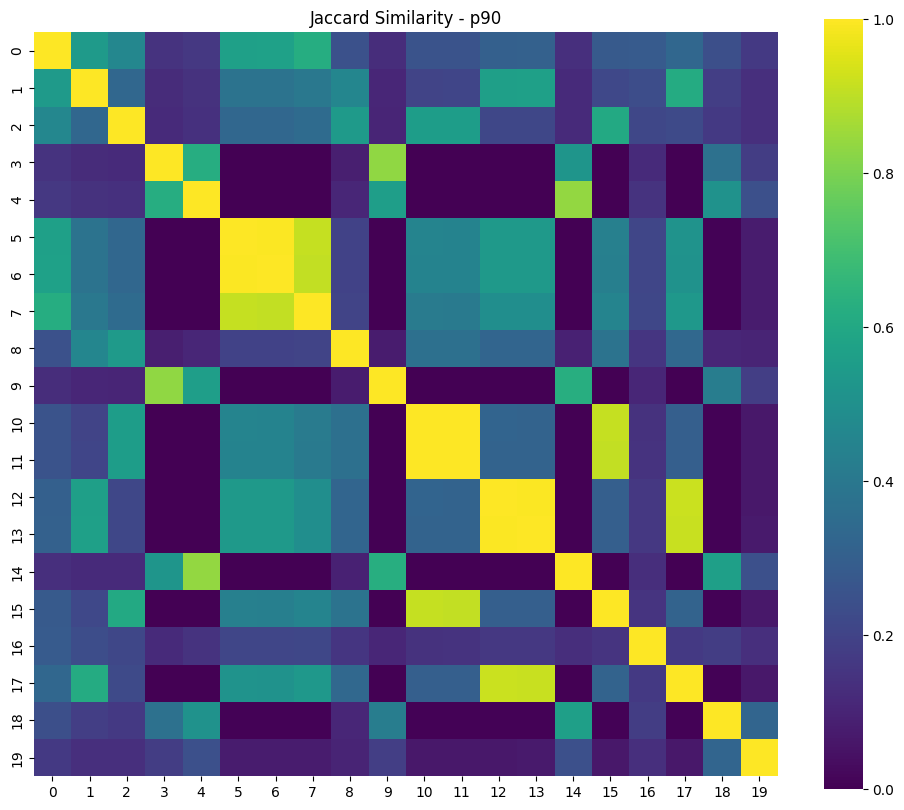

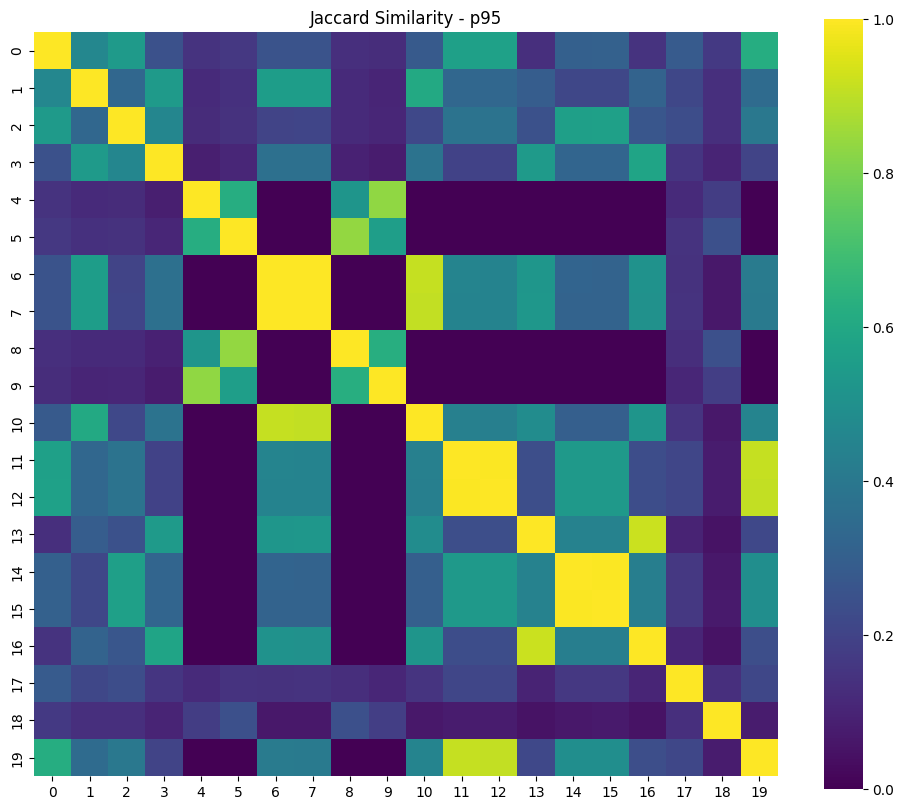

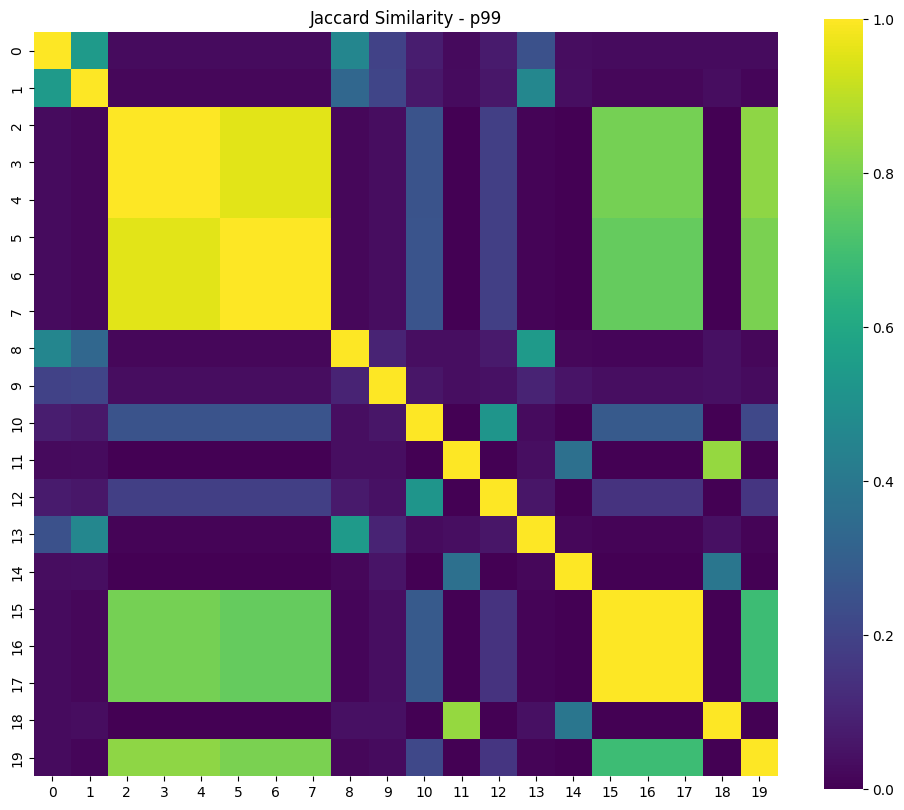

In [42]:
plot_heatmap(jaccard_p90, "p90")
plot_heatmap(jaccard_p95, "p95")
plot_heatmap(jaccard_p99, "p99")

In [95]:
experiments = {
    "P90": result_p90,
    "P95": result_p95,
    "P99": result_p99
}

summary = []

for name, result_df in experiments.items():

    covers = build_cover_sets(
        mining_df,
        result_df
    )

    jac = build_jaccard_matrix(
        covers
    )

    redundancy = average_redundancy(
        jac
    )

    summary.append({
        "experiment": name,
        "avg_jaccard": redundancy
    })

summary = pd.DataFrame(summary)

In [96]:
summary

,experiment,avg_jaccard
0,P90,0.260953
1,P95,0.265125
2,P99,0.264521


#### Experimento 2 - Cobertura

In [74]:
def cumulative_positive_coverage(raw_result, df, positive_set):
    covered = set()

    rows = []

    for i, (_, subgroup, _) in enumerate(raw_result.results):
        mask = subgroup.covers(df)

        subgroup_positives = set(df.index[mask]) & positive_set

        covered |= subgroup_positives

        rows.append({
            "k": i+1,
            "covered_positives": len(covered),
            "coverage": len(covered) / len(positive_set)
        })
    
    return pd.DataFrame(rows)

In [75]:
positives_p90 = set(mining_df.index[mining_df["target_p90"]])
positives_p95 = set(mining_df.index[mining_df["target_p95"]])
positives_p99 = set(mining_df.index[mining_df["target_p99"]])

In [87]:
cov_p90 = cumulative_positive_coverage(
    result_p90,
    mining_df,
    positives_p90
)

cov_p95 = cumulative_positive_coverage(
    result_p95,
    mining_df,
    positives_p95
)

cov_p99 = cumulative_positive_coverage(
    result_p99,
    mining_df,
    positives_p99
)

In [91]:
cov_p90

,k,covered_positives,coverage
0,1,30859,0.662296
1,2,30859,0.662296
2,3,30859,0.662296
3,4,33865,0.726810
4,5,33865,0.726810
5,6,33865,0.726810
6,7,33865,0.726810
7,8,33865,0.726810
8,9,33865,0.726810
9,10,33865,0.726810


In [92]:
cov_p95

,k,covered_positives,coverage
0,1,17588,0.754979
1,2,17588,0.754979
2,3,17588,0.754979
3,4,17588,0.754979
4,5,19294,0.828211
5,6,19294,0.828211
6,7,19294,0.828211
7,8,19294,0.828211
8,9,19294,0.828211
9,10,19294,0.828211


In [90]:
cov_p99

,k,covered_positives,coverage
0,1,2017,0.432833
1,2,2834,0.608155
2,3,2922,0.627039
3,4,2922,0.627039
4,5,2922,0.627039
5,6,2922,0.627039
6,7,2922,0.627039
7,8,2922,0.627039
8,9,3614,0.775536
9,10,3614,0.775536


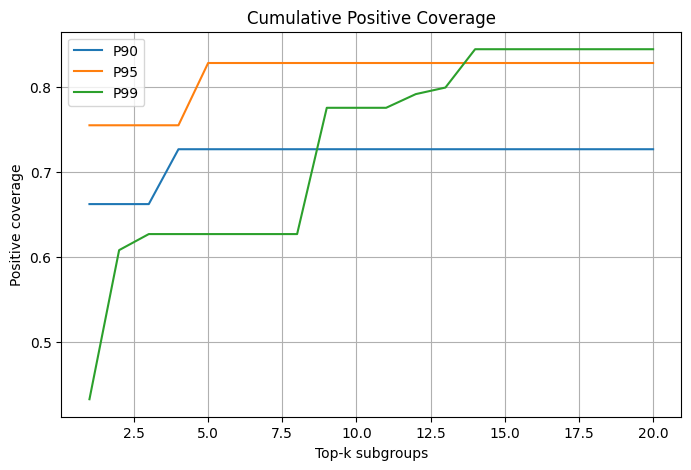

In [48]:
plt.figure(figsize=(8,5))

plt.plot(
    cov_p90["k"],
    cov_p90["coverage"],
    label="P90"
)

plt.plot(
    cov_p95["k"],
    cov_p95["coverage"],
    label="P95"
)

plt.plot(
    cov_p99["k"],
    cov_p99["coverage"],
    label="P99"
)

plt.xlabel("Top-k subgroups")
plt.ylabel("Positive coverage")
plt.title("Cumulative Positive Coverage")

plt.legend()

plt.grid(True)

plt.show()

#### Experimento 3 - Diversidade

In [50]:
def attribute_frequency(result_df):
    counter = Counter()

    for subgroup in result_df["subgroup"]:
        subgroup = str(subgroup)

        attrs = re.findall(r"([a-zA-Z_]+)\s*==", subgroup)

        counter.update(attrs)
    
    return pd.DataFrame(
        counter.items(), 
        columns=["attribute", "frequency"]
    ).sort_values("frequency", ascending=False)

def plot_attribute_frequency(freq_df, title):
    plt.figure(figsize=(10,5))

    plt.bar(freq_df["attribute"], freq_df["frequency"])

    plt.xticks(rotation=45)
    plt.title(title)
    plt.show()

In [51]:
freq_p90 = attribute_frequency(result_p90_df)
freq_p95 = attribute_frequency(result_p95_df)
freq_p99 = attribute_frequency(result_p99_df)

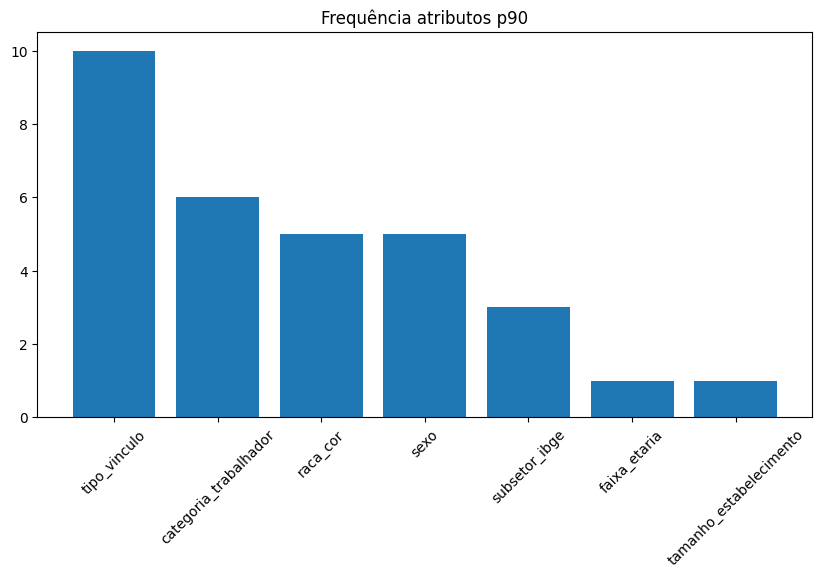

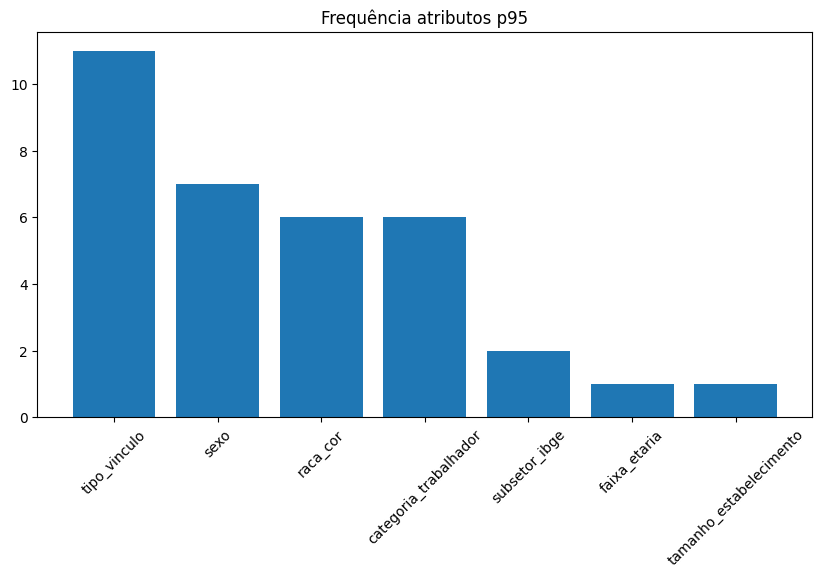

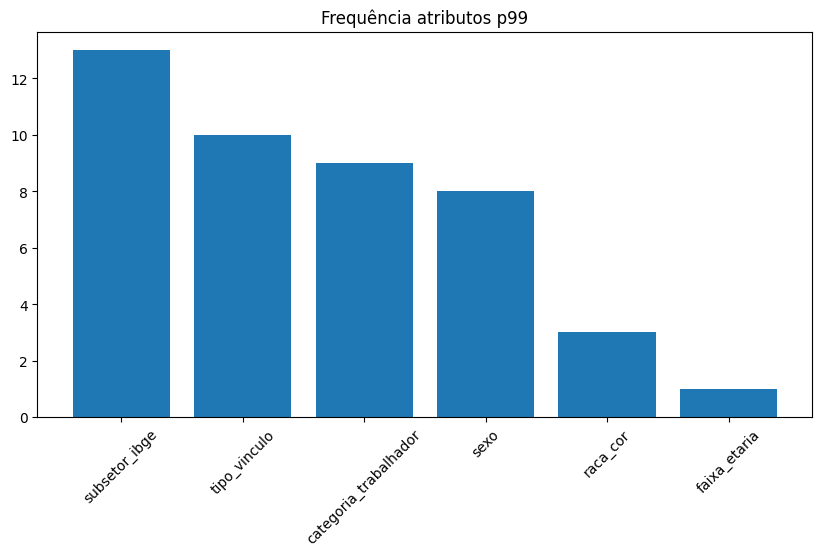

In [52]:
plot_attribute_frequency(freq_p90, "Frequência atributos p90")
plot_attribute_frequency(freq_p95, "Frequência atributos p95")
plot_attribute_frequency(freq_p99, "Frequência atributos p99")

#### Experimento 4 - Entropia dos atributos

In [53]:
def attribute_entropy(result_df):

    counter = Counter()

    for subgroup in result_df["subgroup"]:
        subgroup = str(subgroup)

        attrs = re.findall(
            r"([a-zA-Z_]+)\s*==",
            subgroup
        )

        counter.update(attrs)

    probs = np.array(
        list(counter.values())
    )

    probs = probs / probs.sum()

    return entropy(probs)

In [54]:
summary_entropy = pd.DataFrame({
    "experiment": ["P90","P95","P99"],
    "entropy": [
        attribute_entropy(result_p90_df),
        attribute_entropy(result_p95_df),
        attribute_entropy(result_p99_df)
    ]
})

summary_entropy

,experiment,entropy
0,P90,1.718935
1,P95,1.676783
2,P99,1.600631


#### Experimento 5 - Comparação de Quality Functions para p99

In [63]:
def run_experiment(
    mining_df,
    target_column,
    search_space,
    qf,
    depth=4,
    result_size=20
):

    target = ps.BinaryTarget(
        target_column,
        True
    )

    task = ps.SubgroupDiscoveryTask(
        mining_df,
        target,
        search_space,
        result_set_size=result_size,
        depth=depth,
        qf=qf
    )

    result = ps.BeamSearch(
        beam_width=result_size * 2
    ).execute(task)

    return result

In [56]:
result_qf0 = run_experiment(
    mining_df,
    "target_p99",
    search_space,
    ps.StandardQF(0.0)
)

result_qf05 = run_experiment(
    mining_df,
    "target_p99",
    search_space,
    ps.StandardQF(0.5)
)

result_qf1 = run_experiment(
    mining_df,
    "target_p99",
    search_space,
    ps.StandardQF(1.0)
)

/home/iago/Documents/Projects/Repositories/.venv/lib/python3.12/site-packages/pysubgroup/binary_target.py:508: RuntimeWarning: invalid value encountered in divide
  p_subgroup = np.divide(positives_subgroup, instances_subgroup)


In [57]:
df_qf0 = result_qf0.to_dataframe()
df_qf05 = result_qf05.to_dataframe()
df_qf1 = result_qf1.to_dataframe()

In [63]:
df_qf1

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift
0,0.006230,grau_instrucao_apos_2005=='SUP. COMP',101239,465916,3915,4660,364677,0.217290,0.782710,0.840129,0.159871,0.038671,0.002043,0.010002,3.866390
1,0.005078,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,46778,465916,2834,4660,419138,0.100400,0.899600,0.608155,0.391845,0.060584,0.004357,0.010002,6.057311
2,0.004751,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,54836,465916,2762,4660,411080,0.117695,0.882305,0.592704,0.407296,0.050368,0.004617,0.010002,5.035929
3,0.003787,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,25239,465916,2017,4660,440677,0.054171,0.945829,0.432833,0.567167,0.079916,0.005998,0.010002,7.990160
4,0.002908,raca_cor=='Branca',191983,465916,3275,4660,273933,0.412055,0.587945,0.702790,0.297210,0.017059,0.005056,0.010002,1.705573
5,0.002815,raca_cor=='Branca' AND sexo=='Masculino',107018,465916,2382,4660,358898,0.229694,0.770306,0.511159,0.488841,0.022258,0.006347,0.010002,2.225393
6,0.002740,categoria_trabalhador==' Empregado - Geral inc...,57315,465916,1850,4660,408601,0.123016,0.876984,0.396996,0.603004,0.032278,0.006877,0.010002,3.227194
7,0.002735,grau_instrucao_apos_2005=='SUP. COMP' AND tipo...,57554,465916,1850,4660,408362,0.123529,0.876471,0.396996,0.603004,0.032144,0.006881,0.010002,3.213793
8,0.002704,faixa_etaria=='40 a 49 anos' AND grau_instruca...,28520,465916,1545,4660,437396,0.061213,0.938787,0.331545,0.668455,0.054173,0.007122,0.010002,5.416275
9,0.002691,categoria_trabalhador==' Empregado - Geral inc...,62816,465916,1882,4660,403100,0.134823,0.865177,0.403863,0.596137,0.029961,0.006892,0.010002,2.995512


In [58]:
summary_qf = pd.DataFrame([
    {
        "QF": "0.0",
        "mean_lift": df_qf0["lift"].mean(),
        "max_lift": df_qf0["lift"].max(),
        "mean_quality": df_qf0["quality"].mean()
    },
    {
        "QF": "0.5",
        "mean_lift": df_qf05["lift"].mean(),
        "max_lift": df_qf05["lift"].max(),
        "mean_quality": df_qf05["quality"].mean()
    },
    {
        "QF": "1.0",
        "mean_lift": df_qf1["lift"].mean(),
        "max_lift": df_qf1["lift"].max(),
        "mean_quality": df_qf1["quality"].mean()
    }
])

summary_qf

,QF,mean_lift,max_lift,mean_quality
0,0.0,99.981974,99.981974,0.989998
1,0.5,21.213886,30.911754,0.013878
2,1.0,4.890054,8.275573,0.002961


#### Experimento 6 - Generalização

In [59]:
def subgroup_lift(
    df,
    subgroup,
    target_column
):
    mask = subgroup.covers(df)
    sg_size = mask.sum()

    if sg_size == 0:
        return np.nan
    
    sg_rate = df.loc[mask, target_column].mean()

    base_rate = df[target_column].mean()

    return sg_rate / base_rate

In [60]:
train = mining_df.sample(frac=0.5, random_state=42)
test = mining_df.drop(train.index)

In [64]:
train_result = run_experiment(train, "target_p99", search_space, ps.StandardQF(0.5))

/home/iago/Documents/Projects/Repositories/.venv/lib/python3.12/site-packages/pysubgroup/binary_target.py:508: RuntimeWarning: invalid value encountered in divide
  p_subgroup = np.divide(positives_subgroup, instances_subgroup)


In [65]:
train_df = train_result.to_dataframe()

In [66]:
train_df

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift
0,0.015607,grau_instrucao_apos_2005=='SUP. COMP' AND sexo...,23342,232958,1384,2327,209616,0.100198,0.899802,0.594757,0.405243,0.059292,0.004499,0.009989,5.935800
1,0.015566,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,12595,232958,969,2327,220363,0.054066,0.945934,0.416416,0.583584,0.076935,0.006163,0.009989,7.702059
2,0.015402,"subsetor_ibge=='Instituiçoes de crédito, segur...",551,232958,180,2327,232407,0.002365,0.997635,0.077353,0.922647,0.326679,0.009238,0.009989,32.704096
3,0.015402,categoria_trabalhador==' Contribuinte individu...,551,232958,180,2327,232407,0.002365,0.997635,0.077353,0.922647,0.326679,0.009238,0.009989,32.704096
4,0.015402,categoria_trabalhador==' Contribuinte individu...,551,232958,180,2327,232407,0.002365,0.997635,0.077353,0.922647,0.326679,0.009238,0.009989,32.704096
5,0.014747,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,523,232958,168,2327,232435,0.002245,0.997755,0.072196,0.927804,0.321224,0.009289,0.009989,32.157986
6,0.014747,categoria_trabalhador==' Contribuinte individu...,523,232958,168,2327,232435,0.002245,0.997755,0.072196,0.927804,0.321224,0.009289,0.009989,32.157986
7,0.014747,categoria_trabalhador==' Contribuinte individu...,523,232958,168,2327,232435,0.002245,0.997755,0.072196,0.927804,0.321224,0.009289,0.009989,32.157986
8,0.013838,raca_cor=='Branca' AND subsetor_ibge=='Institu...,467,232958,149,2327,232491,0.002005,0.997995,0.064031,0.935969,0.319058,0.009368,0.009989,31.941156
9,0.013838,categoria_trabalhador==' Contribuinte individu...,467,232958,149,2327,232491,0.002005,0.997995,0.064031,0.935969,0.319058,0.009368,0.009989,31.941156


In [67]:
rows = []

for quality, subgroup, stats in train_result.results:
    train_lift = subgroup_lift(
        train,
        subgroup,
        "target_p99"
    )

    test_lift = subgroup_lift(
        test,
        subgroup,
        "target_p99"
    )

    rows.append({
        "subgroup": str(subgroup),
        "train_lift": train_lift,
        "test_lift": test_lift,
        "drop_pct": (train_lift - test_lift)/train_lift
    })

validation_df = pd.DataFrame(rows)

In [69]:
validation_df[["train_lift", "test_lift", "drop_pct"]].describe()

,train_lift,test_lift,drop_pct
count,20.000000,20.000000,20.000000
mean,25.211654,22.628719,0.073789
std,11.309418,9.531641,0.071939
min,3.859563,3.873157,-0.074565
25%,16.633352,16.926438,0.024374
50%,31.941156,27.568223,0.112832
75%,32.518613,28.881762,0.119290
max,32.704096,29.381644,0.136906


In [70]:
validation_df.sort_values("drop_pct", ascending=False)

,subgroup,train_lift,test_lift,drop_pct
10,categoria_trabalhador==' Contribuinte individu...,31.941156,27.568223,0.136906
8,raca_cor=='Branca' AND subsetor_ibge=='Institu...,31.941156,27.568223,0.136906
9,categoria_trabalhador==' Contribuinte individu...,31.941156,27.568223,0.136906
18,grau_instrucao_apos_2005=='SUP. COMP' AND raca...,31.411764,27.437198,0.126531
19,categoria_trabalhador==' Contribuinte individu...,31.411764,27.437198,0.126531
4,categoria_trabalhador==' Contribuinte individu...,32.704096,28.881762,0.116876
2,"subsetor_ibge=='Instituiçoes de crédito, segur...",32.704096,28.881762,0.116876
3,categoria_trabalhador==' Contribuinte individu...,32.704096,28.881762,0.116876
5,grau_instrucao_apos_2005=='SUP. COMP' AND subs...,32.157986,28.529545,0.112832
6,categoria_trabalhador==' Contribuinte individu...,32.157986,28.529545,0.112832
